# L1 and L2 Regularization with ParmEst

## Regularization Using Prior Parameter Information

Parameter estimation problems can be challenging when the available data are
limited, noisy, or weakly informative for some parameters. In these cases, the
least squares or maximum likelihood objective may have broad valleys, multiple
local optima, or parameter estimates that are physically unreasonable.

One way to incorporate additional information is through **regularization**.
Regularization augments the parameter estimation objective with an additional
term that penalizes deviations from prior parameter values.

Let $\boldsymbol{\theta}_0$ denote a vector of prior or nominal parameter values,
and let $\boldsymbol{F}_{\text{prior}}$ denote a prior Fisher information matrix
(FIM). The prior FIM represents the amount of information available about the
parameters before fitting the current data. This information may come from
previous experiments, previous parameter estimation studies, literature values,
or expert knowledge.

The regularized parameter estimation problem can be written as

$$
   \min_{\boldsymbol{\theta}} \;
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
   +
   R(\boldsymbol{\theta}; \boldsymbol{\theta}_0, \boldsymbol{F}_{\text{prior}})
$$

where $g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})$ is the objective
function from the current parameter estimation problem and
$R(\boldsymbol{\theta}; \boldsymbol{\theta}_0, \boldsymbol{F}_{\text{prior}})$
is the regularization term.

---


### Interpretation of the Prior FIM

The prior FIM provides a way to encode prior information in a form that is
consistent with the local curvature of a parameter estimation objective.

A larger value in $\boldsymbol{F}_{\text{prior}}$ indicates that the prior
information strongly constrains a parameter or parameter combination. A smaller
value indicates weaker prior information. If the prior FIM contains off-diagonal
terms, then the regularization accounts for correlations between parameter
directions.

For L2 regularization, the full prior FIM can be used directly:

$$
   R_{2}
   =
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)^\text{T}
   \boldsymbol{F}_{\text{prior}}
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)
$$

For L1 regularization, a diagonal or otherwise simplified representation is
often used to define parameter-wise weights:

$$
   R_{1,\epsilon}
   =
   \sum_{j=1}^{p}
   w_j
   \sqrt{
      \left(\theta_j - \theta_{0,j}\right)^2
      +
      \epsilon^2
   }
$$

where the weights $w_j$ reflect the strength of the prior information associated
with each parameter.

---

### Maximum Likelihood Estimation and Regularization

The current `parmest` parameter estimation workflow can be interpreted as a
maximum likelihood estimation (MLE) problem when the objective function is
derived from an assumed measurement error distribution.

For example, when Gaussian independent measurement errors are assumed, the
weighted sum of squared errors objective corresponds to the negative
log-likelihood of the observed data, up to additive constants. In this case,
solving

$$
   \min_{\boldsymbol{\theta}} \;
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
$$

is equivalent to finding the maximum likelihood estimate:

$$
   \hat{\boldsymbol{\theta}}_{\text{MLE}}
   =
   \arg\max_{\boldsymbol{\theta}}
   p(\boldsymbol{y} \mid \boldsymbol{x}, \boldsymbol{\theta})
$$

or, equivalently,

$$
   \hat{\boldsymbol{\theta}}_{\text{MLE}}
   =
   \arg\min_{\boldsymbol{\theta}}
   -
   \log
   p(\boldsymbol{y} \mid \boldsymbol{x}, \boldsymbol{\theta})
$$

Regularization modifies this objective by adding prior information about the
parameters. The regularized problem is

$$
   \min_{\boldsymbol{\theta}} \;
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
   +
   R(\boldsymbol{\theta}; \boldsymbol{\theta}_0, \boldsymbol{F}_{\text{prior}})
$$

This can be viewed as a bridge between MLE and Bayesian parameter estimation.

---

### Connection to MAP Estimation

Maximum a posteriori (MAP) estimation incorporates both the likelihood of the
data and a prior distribution over the parameters. The MAP estimate is defined
as

$$
   \hat{\boldsymbol{\theta}}_{\text{MAP}}
   =
   \arg\max_{\boldsymbol{\theta}}
   p(\boldsymbol{\theta} \mid \boldsymbol{x}, \boldsymbol{y})
$$

Using Bayes' rule,

$$
   p(\boldsymbol{\theta} \mid \boldsymbol{x}, \boldsymbol{y})
   \propto
   p(\boldsymbol{y} \mid \boldsymbol{x}, \boldsymbol{\theta})
   p(\boldsymbol{\theta})
$$

so that MAP estimation can be written as

$$
   \hat{\boldsymbol{\theta}}_{\text{MAP}}
   =
   \arg\min_{\boldsymbol{\theta}}
   \left[
      -
      \log p(\boldsymbol{y} \mid \boldsymbol{x}, \boldsymbol{\theta})
      -
      \log p(\boldsymbol{\theta})
   \right]
$$

The first term corresponds to the parameter estimation objective from the
current data. The second term corresponds to a regularization term induced by
the prior distribution.

For example, an L2 regularization term corresponds to a Gaussian prior centered
at $\boldsymbol{\theta}_0$:

$$
   \boldsymbol{\theta}
   \sim
   \mathcal{N}
   \left(
      \boldsymbol{\theta}_0,
      \boldsymbol{F}_{\text{prior}}^{-1}
   \right)
$$

The negative log-prior is proportional to

$$
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)^\text{T}
   \boldsymbol{F}_{\text{prior}}
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)
$$

which is the L2 regularization term.

Similarly, an L1 regularization term can be interpreted as corresponding to a
Laplace-type prior centered at $\boldsymbol{\theta}_0$, with the smoothed L1
form used as a differentiable approximation for numerical optimization.

---

### Regularization Workflow

A typical regularized parameter estimation workflow consists of:

1. Defining the parameter estimation model and objective
   $g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})$
2. Providing prior parameter values $\boldsymbol{\theta}_0$
3. Providing a prior FIM $\boldsymbol{F}_{\text{prior}}$
4. Selecting an L1 or L2 regularization form
5. Solving the regularized parameter estimation problem
6. Comparing the regularized solution to the unregularized MLE solution
7. Assessing whether the prior information improves parameter stability,
   estimability, or physical plausibility

Regularization is especially useful when some parameters are weakly informed by
the current data. In this case, the prior FIM provides additional information
that can stabilize the parameter estimates while still allowing the data to
influence the final solution.

## Import packages

In [92]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_results,
    extract_plot_results,
    results_summary
)
import pyomo.contrib.parmest.parmest as parmest

# set default number of states in the TCLab model
number_tclab_states = 2

## Load and explore experimental data

In [93]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


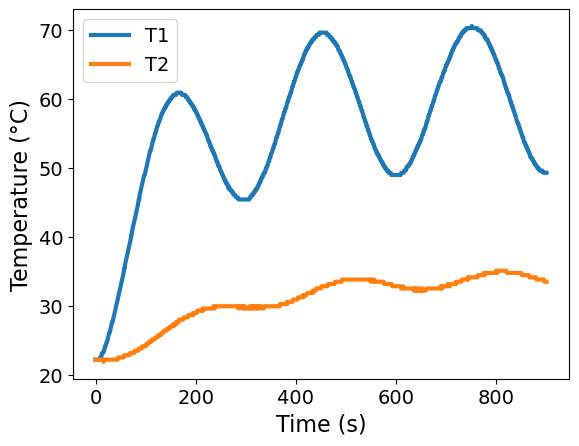

In [94]:
ax = df.plot(x='Time', y=['T1', 'T2'], xlabel='Time (s)', ylabel='Temperature (°C)')

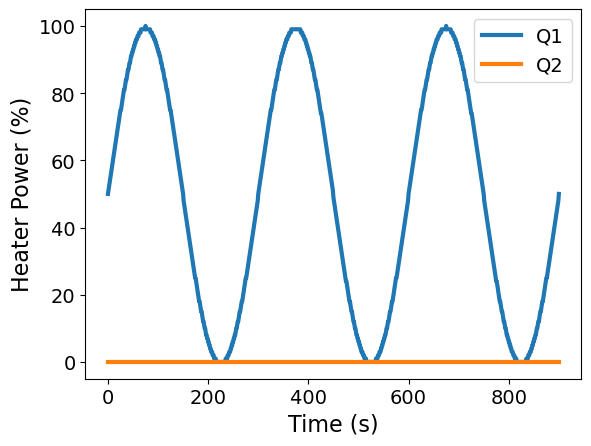

In [95]:
ax = df.plot(x='Time', y=['Q1', 'Q2'], xlabel='Time (s)', ylabel='Heater Power (%)')

## Store in Custom Data Class 

In the file `tclab_pyomo.py`, we defined a `dataclass` for convenience. It is essentially a light weight container to store experimental data.

In [96]:
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values,
    T1=df['T1'].values,
    u1=df['Q1'].values,
    P1=200,
    TS1_data=None,
    T2=df['T2'].values,
    u2=df['Q2'].values,
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

In [97]:
tc_data.to_data_frame().head()

# Define an Experiment object within parmest
TC_Lab_sine_exp = TC_Lab_experiment(data=tc_data, number_of_states=number_tclab_states)

### Physically Motivated Prior Information

For regularization, we define a weakly informative prior using physical intuition,
literature values, and expert knowledge. The purpose of this prior is not to fix
the parameter estimates, but to guide the optimization toward physically
reasonable values when the data are not strongly informative.

The nominal physical parameter values are

$$
U_a = 0.030 \; \text{W/K}, \qquad
U_b = 0.018 \; \text{W/K},
$$

$$
C_{p,H} = 7.5 \; \text{J/K}, \qquad
C_{p,S} = 0.22 \; \text{J/K}.
$$

Here, $U_a$ represents heat loss from the heater to the surroundings, $U_b$
represents heater-to-sensor coupling, $C_{p,H}$ is the heater thermal mass, and
$C_{p,S}$ is the sensor thermal mass. These values reflect the expectation that
the heater has a much larger effective heat capacity than the sensor, while both
thermal conductance parameters are small but nonzero.

Because the estimator uses inverse heat capacities, the prior is transformed to

$$
\boldsymbol{\theta}_0 =
\left[
U_a,\;
U_b,\;
\frac{1}{C_{p,H}},\;
\frac{1}{C_{p,S}}
\right]
\approx
\left[
0.030,\;
0.018,\;
0.133,\;
4.545
\right].
$$

To represent uncertainty in this prior, we specify a diagonal covariance matrix
in the estimator parameterization:

$$
\boldsymbol{\Sigma}_{\text{prior}}
=
\text{diag}\left(0.02,\;0.01,\;0.05,\;0.05\right).
$$

The diagonal form assumes no prior correlations, and the relatively large
variances make the prior weakly informative. The prior Fisher information matrix
is then computed as

$$
\boldsymbol{F}_{\text{prior}}
=
w_{\text{prior}}
\boldsymbol{\Sigma}_{\text{prior}}^{-1},
\qquad
w_{\text{prior}} = 0.05.
$$

This scaled prior FIM is used in the regularization term to discourage
physically unrealistic parameter values while still allowing the experimental
data to dominate the estimate.

In [98]:
# Define a physically motivated prior for the parameters based on literature values and expert knowledge. This will be used to construct the prior FIM for regularization.

import numpy as np
import pandas as pd

# ---- Physically intuitive guesses (Cp-space) ----
theta_phys = pd.Series({
    "Ua": 0.030,   # W/K, ambient loss from heater node
    "Ub": 0.018,   # W/K, heater-to-sensor coupling
    "CpH": 7.5,    # J/K, heater thermal mass
    "CpS": 0.22,   # J/K, sensor thermal mass
})

# 1-sigma uncertainty
sigma_phys = pd.Series({
    "Ua": 0.012,
    "Ub": 0.005,
    "CpH": 1.5,
    "CpS": 0.12,
})

# Transform to estimator parameterization [Ua, Ub, inv_CpH, inv_CpS]
theta0_phys = pd.Series({
    "Ua": theta_phys["Ua"],
    "Ub": theta_phys["Ub"],
    "inv_CpH": 1.0 / theta_phys["CpH"],
    "inv_CpS": 1.0 / theta_phys["CpS"],
})

# Make a covariance with no correlation and large uncertainty to represent weakly informative prior
# Transform the standard deviations to the estimator parameterization using error propagation
sigma_inv_CpH = sigma_phys["CpH"] / (theta_phys["CpH"] ** 2)
sigma_inv_CpS = sigma_phys["CpS"] / (theta_phys["CpS"] ** 2)

sigma_phys_est = pd.Series({
    "Ua": sigma_phys["Ua"],
    "Ub": sigma_phys["Ub"],
    "inv_CpH": sigma_inv_CpH,
    "inv_CpS": sigma_inv_CpS,
})

cov_x = pd.DataFrame(
    np.diag(sigma_phys_est.values ** 2),
    index=["Ua","Ub","inv_CpH","inv_CpS"],
    columns=["Ua","Ub","inv_CpH","inv_CpS"],
)


prior_FIM_phys= pd.DataFrame(
    np.linalg.inv(cov_x.values),
    index=cov_x.index,
    columns=cov_x.columns,
)

# Optional scaling factor to tune regularization strength
prior_weight = 0.5
prior_FIM_phys = prior_weight * prior_FIM_phys


print("theta0_phys:", theta0_phys)
print("prior_FIM_phys:\n", prior_FIM_phys)




theta0_phys: Ua         0.030000
Ub         0.018000
inv_CpH    0.133333
inv_CpS    4.545455
dtype: float64
prior_FIM_phys:
                   Ua       Ub  inv_CpH   inv_CpS
Ua       3472.222222      0.0    0.000  0.000000
Ub          0.000000  20000.0    0.000  0.000000
inv_CpH     0.000000      0.0  703.125  0.000000
inv_CpS     0.000000      0.0    0.000  0.081339


### L2 Regularization

In L2 regularization, the penalty is quadratic in the difference between the
estimated parameters and the prior parameter values.

Using a prior FIM, the L2 regularization term can be written as

$$
   R_{2}(\boldsymbol{\theta}; \boldsymbol{\theta}_0, \boldsymbol{F}_{\text{prior}})
   =
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)^\text{T}
   \boldsymbol{F}_{\text{prior}}
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)
$$

so that the regularized parameter estimation problem becomes

$$
   \min_{\boldsymbol{\theta}} \;
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
   +
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)^\text{T}
   \boldsymbol{F}_{\text{prior}}
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)
$$

This term penalizes parameter values that move far away from the prior values.
The prior FIM determines both the magnitude and correlation structure of the
penalty. Parameters with larger prior information are penalized more strongly
for moving away from their prior values, while correlations in the prior FIM
allow coupled parameter deviations to be represented.

L2 regularization is smooth and differentiable, which makes it convenient for
gradient-based nonlinear optimization solvers.

In [99]:
# Since everything has been labeled properly in the Experiment object, we simply invoke
# parmest's Estimator function to estimate the parameters and add the needed regularization arguments.

solver_options = {
                  'linear_solver': 'ma57',
                  'max_iter': 1000
                  }

pest_regL2_phys = parmest.Estimator([TC_Lab_sine_exp, ], obj_function='SSE', tee=True, solver_options=solver_options, regularization='L2', prior_FIM=prior_FIM_phys, theta_ref=theta0_phys)

obj_phys, theta_phys_est = pest_regL2_phys.theta_est()

print("\nL2 (physical prior) objective:", obj_phys)
print("L2 (physical prior) theta:\n", theta_phys_est)


Ipopt 3.13.2: linear_solver=ma57
max_iter=1000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific

In [100]:
# Calculate covariance of parameter estimates for regularized estimation with physical prior
cov_regL2_phys = pest_regL2_phys.cov_est(method='reduced_hessian')
print("\nCovariance of parameter estimates with L2 regularization and physical prior:\n", cov_regL2_phys)

Ipopt 3.13.2: linear_solver=ma57
max_iter=1000
bound_relax_factor=0
honor_original_bounds=no


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collecti

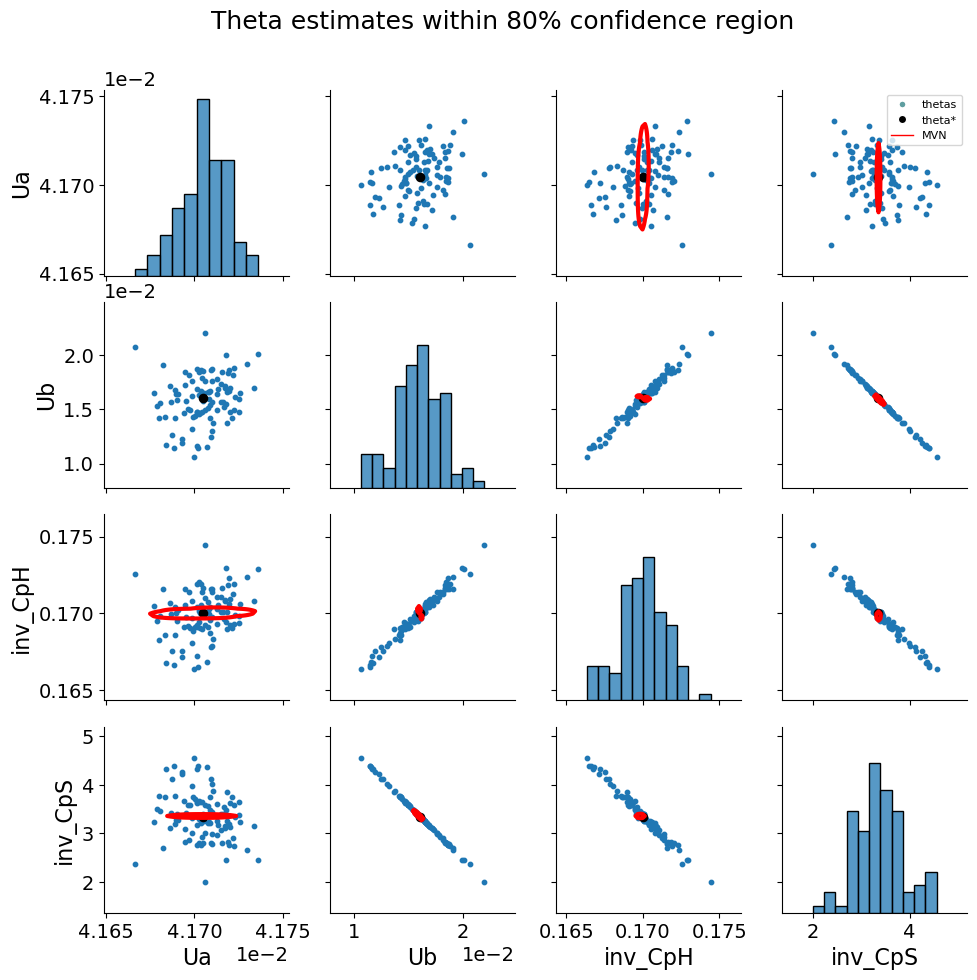

In [101]:
if parmest.graphics.seaborn_available:
    parmest.graphics.pairwise_plot(
        (theta_phys_est, cov_regL2_phys, 100),
        theta_star=theta_phys_est,
        alpha=0.8,
        distributions=['MVN'],
        title='Theta estimates within 80% confidence region',
    )

### L1 Regularization

In L1 regularization, the penalty is based on the absolute deviation between the
estimated parameters and the prior parameter values. Conceptually, the L1
regularization term has the form

$$
   R_{1}(\boldsymbol{\theta}; \boldsymbol{\theta}_0)
   =
   \sum_{j=1}^{p}
   w_j
   \left|
      \theta_j - \theta_{0,j}
   \right|
$$

where $w_j$ is a regularization weight for parameter $\theta_j$.

In practice, the absolute value function is not differentiable at zero. To make
the L1 penalty more suitable for smooth nonlinear optimization, it can be
approximated using a differentiable smoothing term:

$$
   \left|
      \theta_j - \theta_{0,j}
   \right|
   \approx
   \sqrt{
      \left(\theta_j - \theta_{0,j}\right)^2
      +
      \epsilon^2
   }
$$

where $\epsilon > 0$ is a small smoothing parameter.

The smooth L1 regularization term can therefore be written as

$$
   R_{1,\epsilon}(\boldsymbol{\theta}; \boldsymbol{\theta}_0)
   =
   \sum_{j=1}^{p}
   w_j
   \sqrt{
      \left(\theta_j - \theta_{0,j}\right)^2
      +
      \epsilon^2
   }
$$

and the corresponding regularized parameter estimation problem is

$$
   \min_{\boldsymbol{\theta}} \;
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
   +
   \sum_{j=1}^{p}
   w_j
   \sqrt{
      \left(\theta_j - \theta_{0,j}\right)^2
      +
      \epsilon^2
   }
$$

The weights $w_j$ may be chosen using prior information about each parameter.
For example, diagonal entries from a prior FIM can be used to scale the penalty
for each parameter:

$$
   w_j = \left[\boldsymbol{F}_{\text{prior}}\right]_{j,j}
$$

or another user-defined scaling may be selected.

Compared with L2 regularization, L1 regularization penalizes deviations more
linearly. This can make the penalty less sensitive to large deviations, while
still encouraging parameter estimates to remain close to prior values.

In [102]:

# Since everything has been labeled properly in the Experiment object, we simply invoke
# parmest's Estimator function to estimate the parameters.
pest_regL1_phys = parmest.Estimator([TC_Lab_sine_exp, ], obj_function='SSE', tee=True, solver_options=solver_options, regularization='L1', prior_FIM=prior_FIM_phys, theta_ref=theta0_phys)

obj_phys, theta_phys_est = pest_regL1_phys.theta_est()

print("\nL1 (physical prior) objective:", obj_phys)
print("L1 (physical prior) theta:\n", theta_phys_est)


Ipopt 3.13.2: linear_solver=ma57
max_iter=1000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific

In [103]:
# Calculate covariance of parameter estimates for regularized estimation with physical prior
cov_regL1_phys = pest_regL1_phys.cov_est(method='reduced_hessian')

print("\nCovariance of parameter estimates with L1 regularization and physical prior, reduced hessian:\n", cov_regL1_phys)

Ipopt 3.13.2: linear_solver=ma57
max_iter=1000
bound_relax_factor=0
honor_original_bounds=no


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collecti

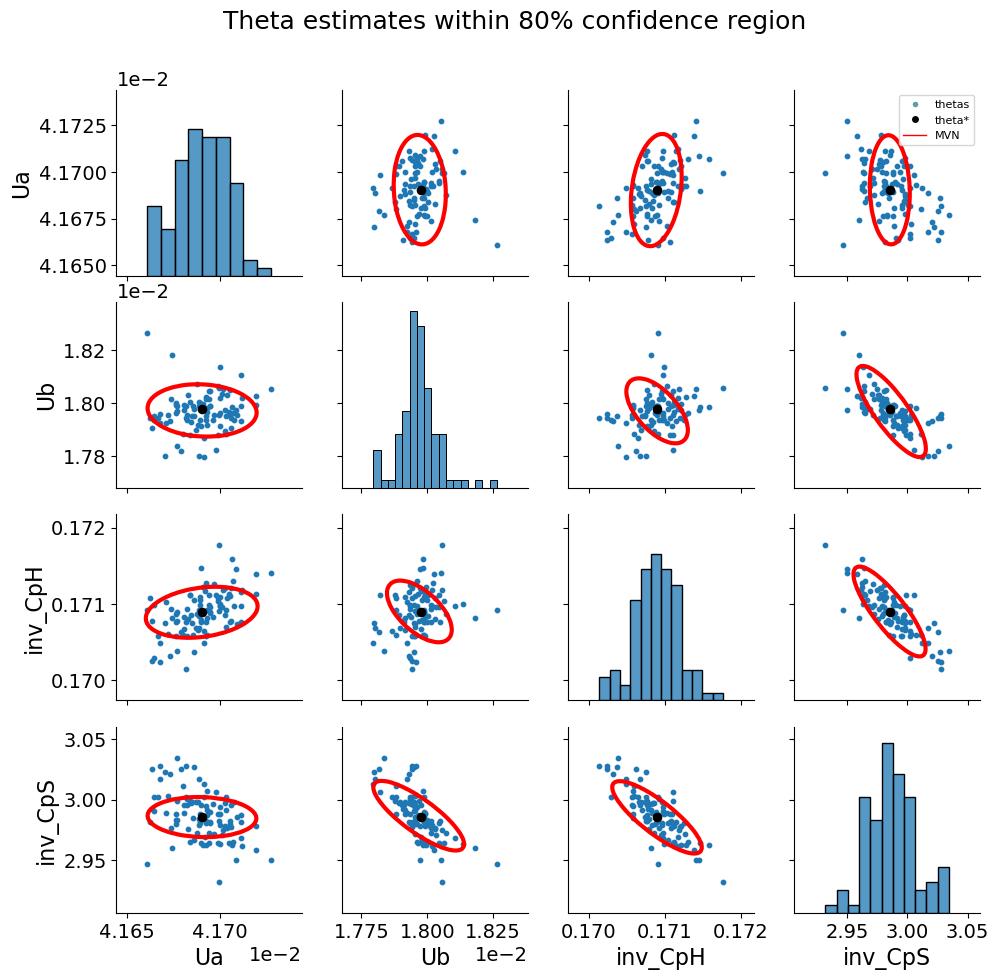

In [104]:
if parmest.graphics.seaborn_available:
    parmest.graphics.pairwise_plot(
        (theta_phys_est, cov_regL1_phys, 100),
        theta_star=theta_phys_est,
        alpha=0.8,
        distributions=['MVN'],
        title='Theta estimates within 80% confidence region',
    )

## Activity: How does strength of prior affect the ?

The goal of using regularization is to prevent singularity in the covariance results. Another way to say this is regularization raises the minimum eigenvalue of the covariance matrix, improving the overall estimability.

In the cell below, the main control is a variable, prior_weight which is previously set to 0.05. Adjust prior weight, and recalculate the covariance matrix to see the effect on the minimum eigenvalue with L2 regularization. When does the covariance matrix become singular?

In [110]:
# Redefine the prior_FIM_phys with a scaling factor to demonstrate tuning regularization strength
prior_FIM_phys= pd.DataFrame(
    np.linalg.inv(cov_x.values),
    index=cov_x.index,
    columns=cov_x.columns,
)
prior_weight = 1E-9
prior_FIM_phys = prior_weight * prior_FIM_phys

In [111]:
# Calculate the parameter estimates with the new scaled prior_FIM_phys to demonstrate tuning regularization strength
pest_regL2_phys = parmest.Estimator([TC_Lab_sine_exp, ], obj_function='SSE', solver_options=solver_options, regularization='L2', prior_FIM=prior_FIM_phys, theta_ref=theta0_phys)
obj_physL2, theta_phys_estL2 = pest_regL2_phys.theta_est()

# Calculate covariance of parameter estimates for regularized estimation with physical prior
cov_regL2_phys = pest_regL2_phys.cov_est(method='reduced_hessian')

In [112]:
# Repeat with L1 regularization and scaled prior_FIM_phys to demonstrate tuning regularization strength
pest_regL1_phys = parmest.Estimator([TC_Lab_sine_exp, ], obj_function='SSE', solver_options=solver_options, regularization='L1', prior_FIM=prior_FIM_phys, theta_ref=theta0_phys)
obj_physL1, theta_phys_estL1 = pest_regL1_phys.theta_est()

# Calculate covariance of parameter estimates for regularized estimation with physical prior
cov_regL1_phys = pest_regL1_phys.cov_est(method='reduced_hessian')


In [113]:
# Calculate the minimum eigenvalue of the covariance matrix to check for near-singularity
trace_l2 = np.trace(cov_regL2_phys)
print("Trace of the covariance matrix (L2):", trace_l2)
determinant_l2 = np.linalg.det(cov_regL2_phys)
print("Determinant of the covariance matrix (L2):", determinant_l2)
eigenvalues_l2 = np.linalg.eigvals(cov_regL2_phys)
min_eigenvalue_l2 = np.min(eigenvalues_l2)
print("Minimum eigenvalue of the covariance matrix (L2):", min_eigenvalue_l2)


trace_l1 = np.trace(cov_regL1_phys)
print("\nTrace of the covariance matrix (L1):", trace_l1)
determinant_l1 = np.linalg.det(cov_regL1_phys)
print("Determinant of the covariance matrix (L1):", determinant_l1)
eigenvalues_l1 = np.linalg.eigvals(cov_regL1_phys)
min_eigenvalue_l1 = np.min(eigenvalues_l1)
print("Minimum eigenvalue of the covariance matrix (L1):", min_eigenvalue_l1)

Trace of the covariance matrix (L2): 34983948.742975645
Determinant of the covariance matrix (L2): 5.058005476909786e-19
Minimum eigenvalue of the covariance matrix (L2): 1.3205234273554445e-10

Trace of the covariance matrix (L1): 97801.25184519452
Determinant of the covariance matrix (L1): 1.592397660508427e-21
Minimum eigenvalue of the covariance matrix (L1): 1.3921292987395282e-10


In [114]:
# Print thetas, objectives, and covariance eigenvalues for comparison
print("\nL2 (physical prior, scaled) objective:", obj_physL2)
print("L2 (physical prior, scaled) theta:\n", theta_phys_estL2)
print("L2 (physical prior, scaled) covariance:\n", cov_regL2_phys)

print("\nL1 (physical prior, scaled) objective:", obj_physL1)
print("L1 (physical prior, scaled) theta:\n", theta_phys_estL1)
print("L1 (physical prior, scaled) covariance:\n", cov_regL1_phys)
  


L2 (physical prior, scaled) objective: 53.77399284745084
L2 (physical prior, scaled) theta:
 Ua         0.041705
Ub         0.017063
inv_CpH    0.170700
inv_CpS    3.138277
dtype: float64
L2 (physical prior, scaled) covariance:
                    Ua            Ub       inv_CpH       inv_CpS
Ua       1.866396e-10 -4.342390e-10  1.446837e-09  1.271496e-08
Ub      -4.334623e-10  9.121022e+02  6.109303e+02 -1.786274e+05
inv_CpH  1.447351e-09  6.109303e+02  4.092039e+02 -1.196454e+05
inv_CpS  1.255760e-08 -1.786274e+05 -1.196454e+05  3.498263e+07

L1 (physical prior, scaled) objective: 53.773993021100104
L1 (physical prior, scaled) theta:
 Ua         0.041705
Ub         0.017974
inv_CpH    0.171315
inv_CpS    2.968451
dtype: float64
L1 (physical prior, scaled) covariance:
                    Ua            Ub       inv_CpH       inv_CpS
Ua       1.866396e-10  1.227168e-12  1.770035e-09 -6.914362e-08
Ub       1.228651e-12  3.123654e+00  2.125492e+00 -5.527052e+02
inv_CpH  1.770036e-09  2.12